# NE-EpiGuard — Feature Engineering + Model Training + SHAP
## Notebook 2

---

### Pipeline Overview
```
Feature Engineering
      ↓
Baseline Model Testing (6 models + MLflow)
      ↓
Hyperparameter Tuning (top 3 models)
      ↓
Stacking Ensemble
      ↓
SHAP Explainability
      ↓
Final Model
```
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import os


#ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import shap


# MLFlow 
import mlflow


# Directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)
os.makedirs('mlflow', exist_ok=True)


# MLflow setup
mlflow.set_tracking_uri('file:///D:/NE-EpiGuard/mlflow')
mlflow.set_experiment('NE-EpiGuard-Disease-Prediction')

print('All imports successful')
print('MLflow tracking URI:', mlflow.get_tracking_uri())

All imports successful
MLflow tracking URI: file:///D:/NE-EpiGuard/mlflow


## 2. Load Data

In [3]:
data = pd.read_csv('Data/northeast_waterborne.csv')
print('Shape:', data.shape)
print('Target Distribution:')
print(data['disease'].value_counts())

Shape: (405074, 39)
Target Distribution:
disease
No_Disease       113645
Typhoid           55454
Dysentery         49956
Giardiasis        46087
Cholera           42565
Hepatitis_E       34769
Hepatitis_A       34063
Leptospirosis     28535
Name: count, dtype: int64


## 3. Feature Engineering

### 3.1 Drop Weak/Redundant Columns

In [4]:
columns_drop = [
    'district', 'latitude', 'longitude',
    'population_density', 'gender'  
]

data = data.drop(columns=columns_drop)

print('Dropped:', columns_drop)
print('Remaining shape:', data.shape)

Dropped: ['district', 'latitude', 'longitude', 'population_density', 'gender']
Remaining shape: (405074, 34)


### 3.2 Ordinal Encoding (risk-ordered categories)

In [5]:
# Handwash Column 
hand_map = {
    'Never': 0, 'Sometimes': 1,
    'Always': 2
}

data['handwashing_practice'] = data['handwashing_practice'].map(hand_map)


# Water Treatment
water_map = {
    'Untreated': 0, 'Boiled': 1,
    'Filtered': 2, 'Chlorinated': 3
}

data['water_treatment'] = data['water_treatment'].map(water_map)


# Season Column
season_map = {
    'Winter': 0, 'Summer': 1, 
    'Monsoon': 2, 'Post-Monsoon': 3
}

data['season'] = data['season'].map(season_map)


# Water source — ordinal risk order
ws_map = {
    'River': 0, 'Pond': 1, 'Open Well': 2, 'Rainwater': 3,
    'Tanker': 4, 'Borewell': 5, 'Piped': 6
}

data['water_source'] = data['water_source'].map(ws_map)


# Toilet access — binary
data['toilet_access'] = data['toilet_access'].map({0: 0, 1: 1})
if data['toilet_access'].dtype == object:
    data['toilet_access'] = LabelEncoder().fit_transform(data['toilet_access'])

print('Ordinal encoding done')
print(data[['handwashing_practice', 'water_treatment', 'water_source', 'season']].head())

Ordinal encoding done
   handwashing_practice  water_treatment  water_source  season
0                     0                0             5       3
1                     2                3             6       1
2                     1                0             4       3
3                     0                0             0       3
4                     2                1             0       3


### 3.3 Label Encoding (state)

In [6]:
le_state = LabelEncoder()
data['state'] = le_state.fit_transform(data['state'])

print('State encoding:')
for i, cls in enumerate(le_state.classes_):
    print(f'{cls} -> {i}')

State encoding:
Arunachal Pradesh -> 0
Assam -> 1
Manipur -> 2
Meghalaya -> 3
Mizoram -> 4
Nagaland -> 5
Sikkim -> 6
Tripura -> 7


### 3.4 Cyclical Encoding for Month

In [7]:
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
data = data.drop(columns=['month'])

print('Month cyclical encoding done')
print(data[['month_sin', 'month_cos']].head())

Month cyclical encoding done
   month_sin     month_cos
0  -0.500000  8.660254e-01
1   1.000000  6.123234e-17
2  -0.866025  5.000000e-01
3  -0.866025  5.000000e-01
4  -0.500000  8.660254e-01


### 3.5 Log Transform Skewed Features

In [8]:
logs_columns = [
    'fecal_coliform_per_100ml',
    'total_coliform_per_100ml'
]

for col in logs_columns:
    data[col] = np.log1p(data[col])
    print(f'log1p applied to {col} - new range: {data[col].min():.2f} to {data[col].max():.2f}')

log1p applied to fecal_coliform_per_100ml - new range: 0.00 to 8.52
log1p applied to total_coliform_per_100ml - new range: 0.00 to 9.21


### 3.6 Engineered Features

In [9]:
# Feature 1
symptons_columns = [
    'symptom_diarrhea', 'symptom_vomiting', 'symptom_fever',
    'symptom_abdominal_pain', 'symptom_dehydration', 'symptom_jaundice',
    'symptom_bloody_stool', 'symptom_skin_rash'
]

data['symptom_count'] = data[symptons_columns].sum(axis=1)

# Feature 2
data['source_treatment_risk'] = (
    6 - data['water_source'] 
) + (3 - data['handwashing_practice']
    )

# Feature 3
data['age_hygiene_risk'] = data['age'] * (2 - data['handwashing_practice'])

# Feature 4: contamination severity index
data['contamination_index'] = (
    data['fecal_coliform_per_100ml'] +
    data['total_coliform_per_100ml'] +
    data['turbidity_ntu'] / 10
)

print('Engineered features created:')
print('  symptom_count, source_treatment_risk, age_hygiene_risk, contamination_index')
print('Current shape:', data.shape)



Engineered features created:
  symptom_count, source_treatment_risk, age_hygiene_risk, contamination_index
Current shape: (405074, 39)


### 3.7 Encode Target Variable

In [10]:
le_encoder = LabelEncoder()
data['disease_encoded'] = le_encoder.fit_transform(data['disease'])

print('Target encoding: ')
for i, cls in enumerate(le_encoder.classes_):
    print(f'{cls} -> {i}')

Target encoding: 
Cholera -> 0
Dysentery -> 1
Giardiasis -> 2
Hepatitis_A -> 3
Hepatitis_E -> 4
Leptospirosis -> 5
No_Disease -> 6
Typhoid -> 7


### 3.8 Train/Test Split

In [12]:
feature_cols = [
    col for col in data.columns if col not in ['disease', 'disease_encoded']
]

X = data[feature_cols]   # string nahi, list pass karo
y = data['disease_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print('Features  :', len(feature_cols))
print('\nTrain class distribution:')
print(pd.Series(y_train).value_counts().sort_index())

Train size: (324059, 38)
Test size : (81015, 38)
Features  : 38

Train class distribution:
disease_encoded
0    34052
1    39965
2    36870
3    27250
4    27815
5    22828
6    90916
7    44363
Name: count, dtype: int64


### 3.9 Feature Scaling

In [13]:
# Columns that need scaling (exclude binary flags and already-encoded ordinals)
scale_cols = [
    'age', 'water_quality_index', 'ph', 'turbidity_ntu',
    'dissolved_oxygen_mg_l', 'bod_mg_l', 'fecal_coliform_per_100ml',
    'total_coliform_per_100ml', 'tds_mg_l', 'nitrate_mg_l',
    'fluoride_mg_l', 'arsenic_ug_l', 'open_defecation_rate',
    'sewage_treatment_pct', 'avg_temperature_c', 'avg_rainfall_mm',
    'avg_humidity_pct', 'symptom_count', 'source_treatment_risk',
    'age_hygiene_risk', 'contamination_index', 'month_sin', 'month_cos'
]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])



print('Scaling done and scaler saved')
print('Final feature set:', list(X_train.columns))

Scaling done and scaler saved
Final feature set: ['state', 'age', 'water_source', 'water_treatment', 'water_quality_index', 'ph', 'turbidity_ntu', 'dissolved_oxygen_mg_l', 'bod_mg_l', 'fecal_coliform_per_100ml', 'total_coliform_per_100ml', 'tds_mg_l', 'nitrate_mg_l', 'fluoride_mg_l', 'arsenic_ug_l', 'open_defecation_rate', 'toilet_access', 'sewage_treatment_pct', 'handwashing_practice', 'season', 'avg_temperature_c', 'avg_rainfall_mm', 'avg_humidity_pct', 'flooding', 'symptom_diarrhea', 'symptom_vomiting', 'symptom_fever', 'symptom_abdominal_pain', 'symptom_dehydration', 'symptom_jaundice', 'symptom_bloody_stool', 'symptom_skin_rash', 'month_sin', 'month_cos', 'symptom_count', 'source_treatment_risk', 'age_hygiene_risk', 'contamination_index']


---
## 4. Baseline Model Testing + MLflow

### Helper Functions

In [14]:
def evaluate_model(model, X_test, y_test, le_target):
    y_pred = model.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    accuracy = accuracy_score(y_test, y_pred)
    # Per-class recall for critical diseases
    report = classification_report(y_test, y_pred,
                                    target_names=le_target.classes_,
                                    output_dict=True)
    leptospirosis_recall = report['Leptospirosis']['recall']
    cholera_recall = report['Cholera']['recall']
    return {
        'macro_f1': round(macro_f1, 4),
        'accuracy': round(accuracy, 4),
        'leptospirosis_recall': round(leptospirosis_recall, 4),
        'cholera_recall': round(cholera_recall, 4)
    }


def plot_confusion_matrix(model, X_test, y_test, le_target, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    path = f'plots/cm_{model_name.replace(" ", "_")}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    return path


results = {}
print('Helper functions ready')

Helper functions ready


### 4.1 Logistic Regression (Baseline)

2026/08/05 08:13:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


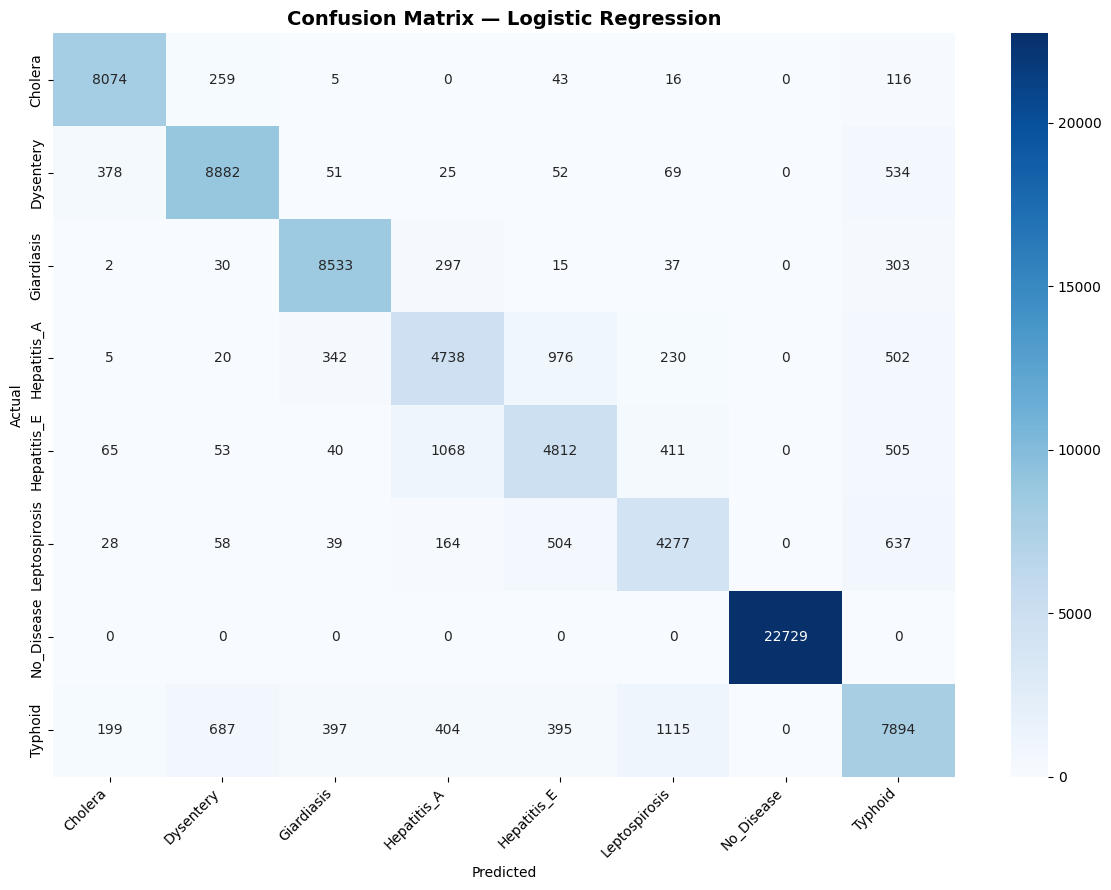

=== Logistic Regression ===
Macro F1  : 0.8243
Accuracy  : 0.8633
Lepto Recall: 0.7494
Cholera Recall: 0.9484


In [15]:
with mlflow.start_run(run_name='LogisticRegression_baseline'):

    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        multi_class='multinomial'
    )
    lr.fit(X_train, y_train)

    metrics = evaluate_model(lr, X_test, y_test, le_encoder)
    results['Logistic Regression'] = metrics

    # Log to MLflow
    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('max_iter', 1000)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lr, 'logistic_regression')

    # Confusion matrix
    cm_path = plot_confusion_matrix(lr, X_test, y_test, le_encoder, 'Logistic Regression')
    mlflow.log_artifact(cm_path)

    print('=== Logistic Regression ===')
    print('Macro F1  :', metrics['macro_f1'])
    print('Accuracy  :', metrics['accuracy'])
    print('Lepto Recall:', metrics['leptospirosis_recall'])
    print('Cholera Recall:', metrics['cholera_recall'])

### 4.2 Random Forest (Baseline)

2026/08/05 08:15:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


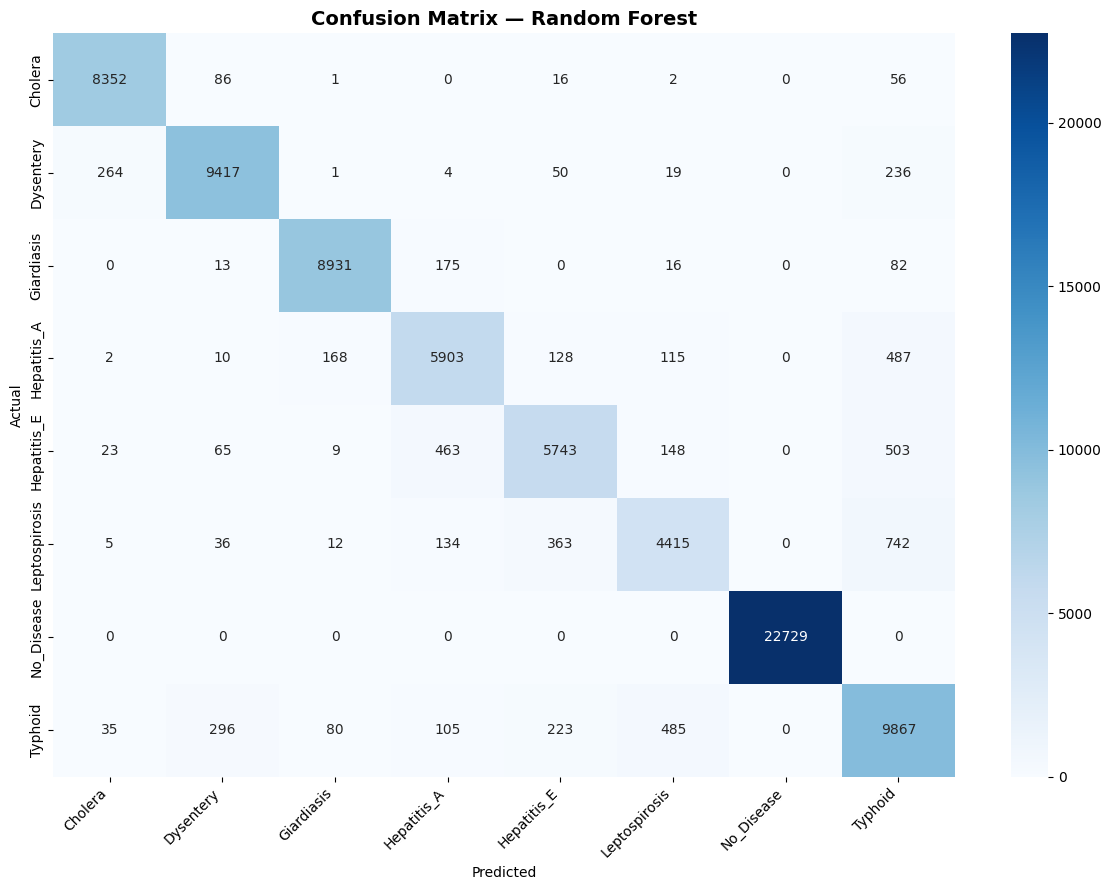

=== Random Forest ===
Macro F1  : 0.9091
Accuracy  : 0.9302
Lepto Recall: 0.7736
Cholera Recall: 0.9811


In [16]:
with mlflow.start_run(run_name='RandomForest_baseline'):

    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    metrics = evaluate_model(rf, X_test, y_test, le_encoder)
    results['Random Forest'] = metrics

    mlflow.log_param('model', 'RandomForest')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(rf, 'random_forest')

    cm_path = plot_confusion_matrix(rf, X_test, y_test, le_encoder, 'Random Forest')
    mlflow.log_artifact(cm_path)

    print('=== Random Forest ===')
    print('Macro F1  :', metrics['macro_f1'])
    print('Accuracy  :', metrics['accuracy'])
    print('Lepto Recall:', metrics['leptospirosis_recall'])
    print('Cholera Recall:', metrics['cholera_recall'])

### 4.3 Extra Tree (Baseline)

2026/08/05 08:17:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


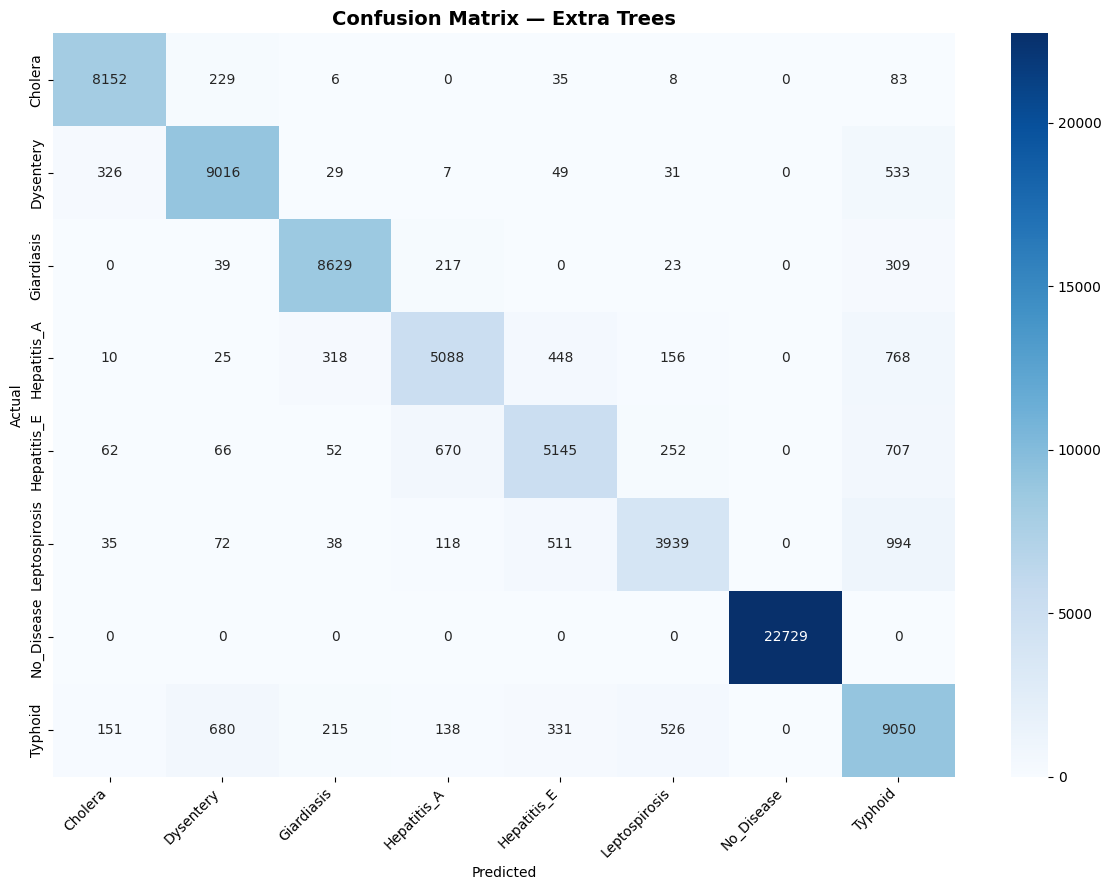

=== Extra Trees ===
Macro F1  : 0.8534
Accuracy  : 0.8856
Lepto Recall: 0.6902
Cholera Recall: 0.9576


In [17]:
with mlflow.start_run(run_name='ExtraTrees_baseline'):

    et = ExtraTreesClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    et.fit(X_train, y_train)

    metrics = evaluate_model(et, X_test, y_test, le_encoder)
    results['Extra Trees'] = metrics

    mlflow.log_param('model', 'ExtraTrees')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(et, 'extra_trees')

    cm_path = plot_confusion_matrix(et, X_test, y_test, le_encoder, 'Extra Trees')
    mlflow.log_artifact(cm_path)

    print('=== Extra Trees ===')
    print('Macro F1  :', metrics['macro_f1'])
    print('Accuracy  :', metrics['accuracy'])
    print('Lepto Recall:', metrics['leptospirosis_recall'])
    print('Cholera Recall:', metrics['cholera_recall'])

### 4.4 XGBoost (Baseline)

2026/08/05 08:18:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


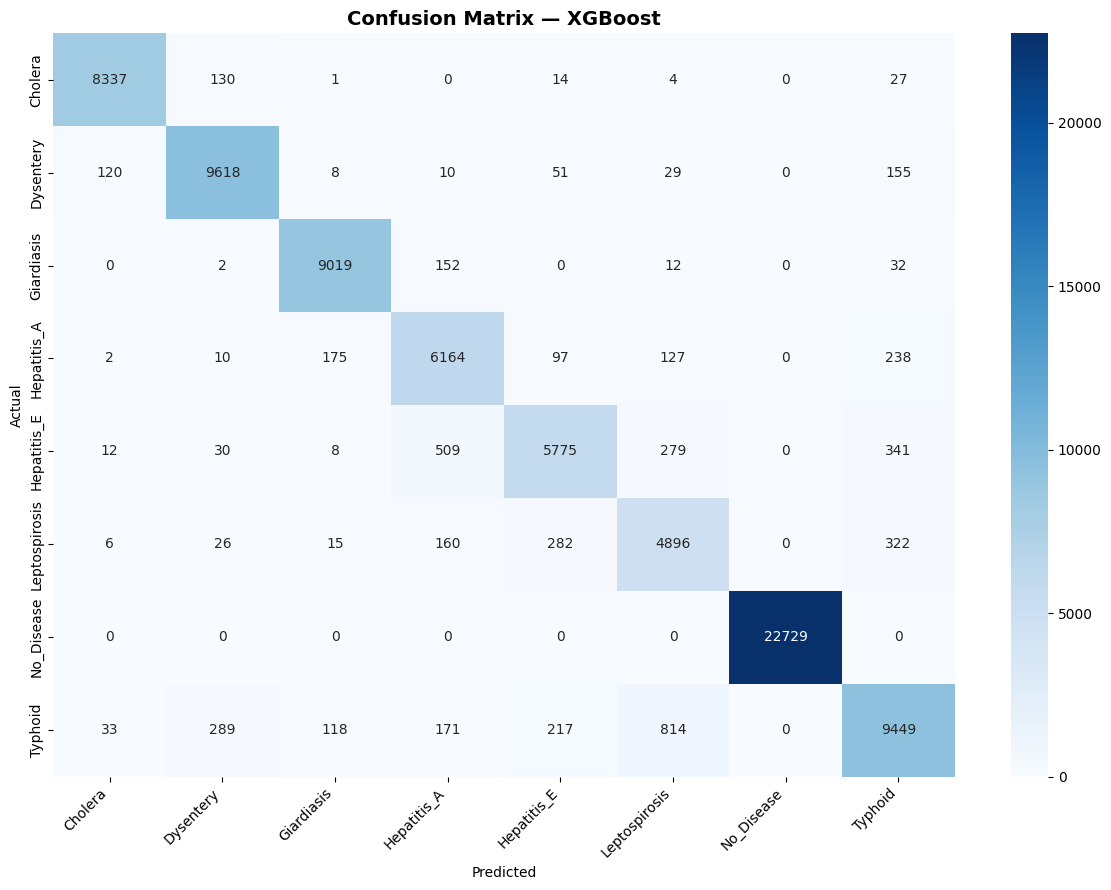

=== XGBoost ===
Macro F1  : 0.9188
Accuracy  : 0.9379
Lepto Recall: 0.8579
Cholera Recall: 0.9793


In [18]:
with mlflow.start_run(run_name='XGBoost_baseline'):

    # Compute class weights for XGBoost
    from sklearn.utils.class_weight import compute_sample_weight
    sample_weights = compute_sample_weight('balanced', y_train)

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
    xgb.fit(X_train, y_train, sample_weight=sample_weights)

    metrics = evaluate_model(xgb, X_test, y_test, le_encoder)
    results['XGBoost'] = metrics

    mlflow.log_param('model', 'XGBoost')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(xgb, 'xgboost')

    cm_path = plot_confusion_matrix(xgb, X_test, y_test, le_encoder, 'XGBoost')
    mlflow.log_artifact(cm_path)

    print('=== XGBoost ===')
    print('Macro F1  :', metrics['macro_f1'])
    print('Accuracy  :', metrics['accuracy'])
    print('Lepto Recall:', metrics['leptospirosis_recall'])
    print('Cholera Recall:', metrics['cholera_recall'])

### 4.5 LightGBM (Baseline)

2026/08/05 08:23:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


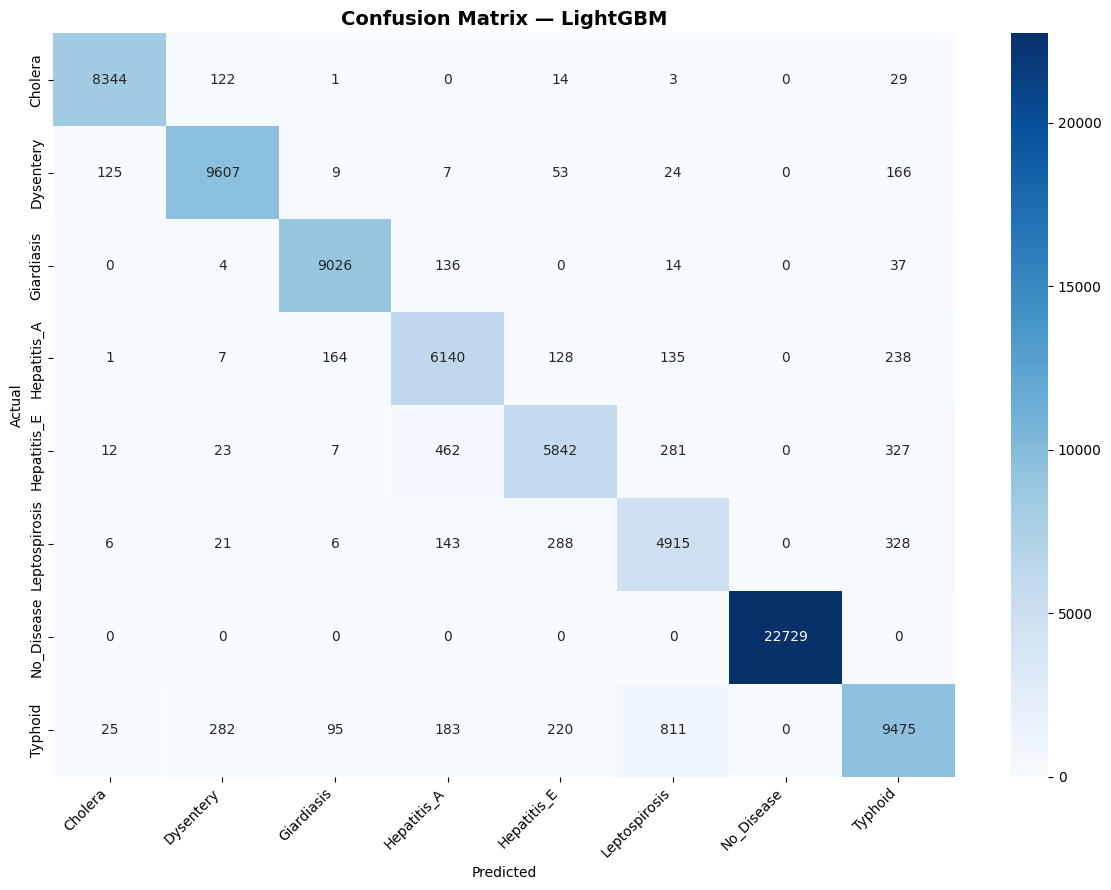

=== LightGBM ===
Macro F1  : 0.9204
Accuracy  : 0.9391
Lepto Recall: 0.8612
Cholera Recall: 0.9801


In [20]:
with mlflow.start_run(run_name='LightGBM_baseline'):

    lgbm = LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        verbosity=-1
    )
    lgbm.fit(X_train, y_train)

    metrics = evaluate_model(lgbm, X_test, y_test, le_encoder)
    results['LightGBM'] = metrics

    mlflow.log_param('model', 'LightGBM')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lgbm, 'lightgbm')

    cm_path = plot_confusion_matrix(lgbm, X_test, y_test, le_encoder, 'LightGBM')
    mlflow.log_artifact(cm_path)

    print('=== LightGBM ===')
    print('Macro F1  :', metrics['macro_f1'])
    print('Accuracy  :', metrics['accuracy'])
    print('Lepto Recall:', metrics['leptospirosis_recall'])
    print('Cholera Recall:', metrics['cholera_recall'])

### 4.6 CatBoost (Baseline)

2026/08/05 08:25:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


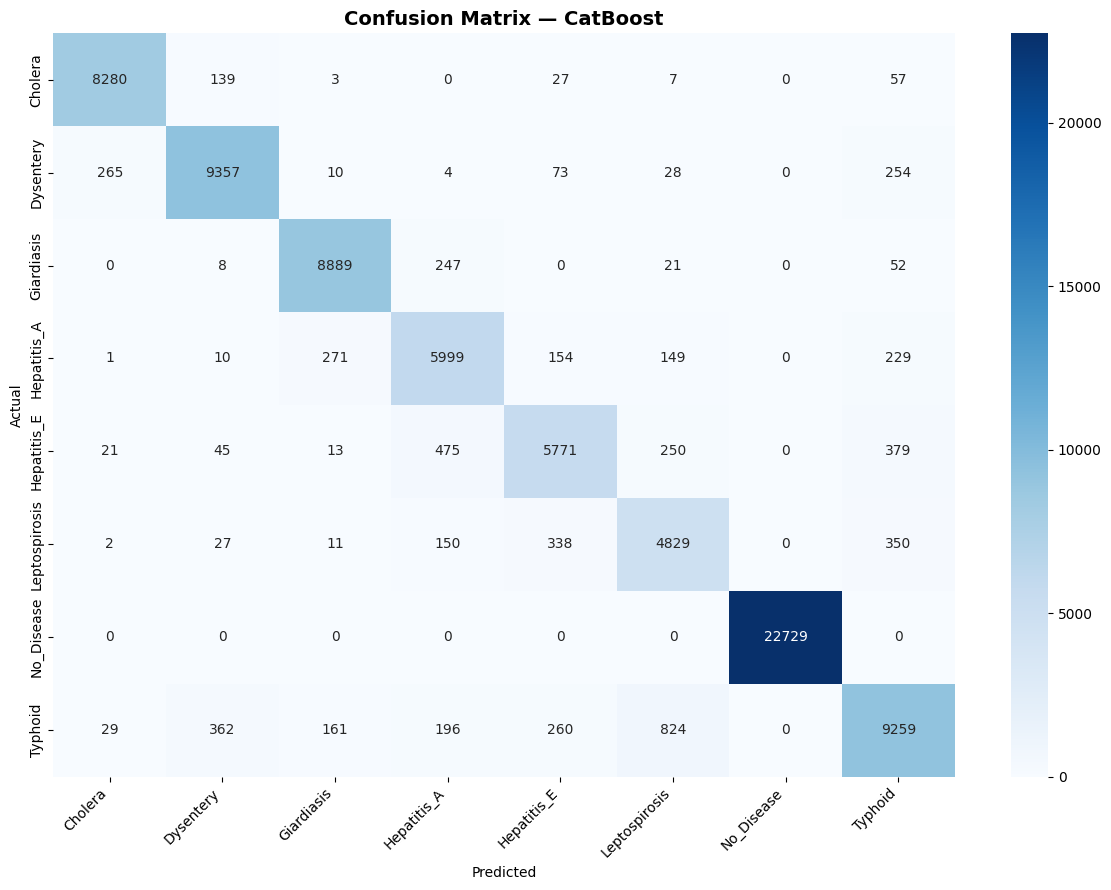

=== CatBoost ===
Macro F1  : 0.9062
Accuracy  : 0.9271
Lepto Recall: 0.8462
Cholera Recall: 0.9726


In [22]:
with mlflow.start_run(run_name='CatBoost_baseline'):

    cat = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )
    cat.fit(X_train, y_train)

    metrics = evaluate_model(cat, X_test, y_test, le_encoder)
    results['CatBoost'] = metrics

    mlflow.log_param('model', 'CatBoost')
    mlflow.log_param('iterations', 200)
    mlflow.log_param('depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(cat, 'catboost')

    cm_path = plot_confusion_matrix(cat, X_test, y_test, le_encoder, 'CatBoost')
    mlflow.log_artifact(cm_path)

    print('=== CatBoost ===')
    print('Macro F1  :', metrics['macro_f1'])
    print('Accuracy  :', metrics['accuracy'])
    print('Lepto Recall:', metrics['leptospirosis_recall'])
    print('Cholera Recall:', metrics['cholera_recall'])

### 4.7 Baseline Results Comparison

=== BASELINE MODEL COMPARISON ===
                     macro_f1  accuracy  leptospirosis_recall  cholera_recall
LightGBM               0.9204    0.9391                0.8612          0.9801
XGBoost                0.9188    0.9379                0.8579          0.9793
Random Forest          0.9091    0.9302                0.7736          0.9811
CatBoost               0.9062    0.9271                0.8462          0.9726
Extra Trees            0.8534    0.8856                0.6902          0.9576
Logistic Regression    0.8243    0.8633                0.7494          0.9484


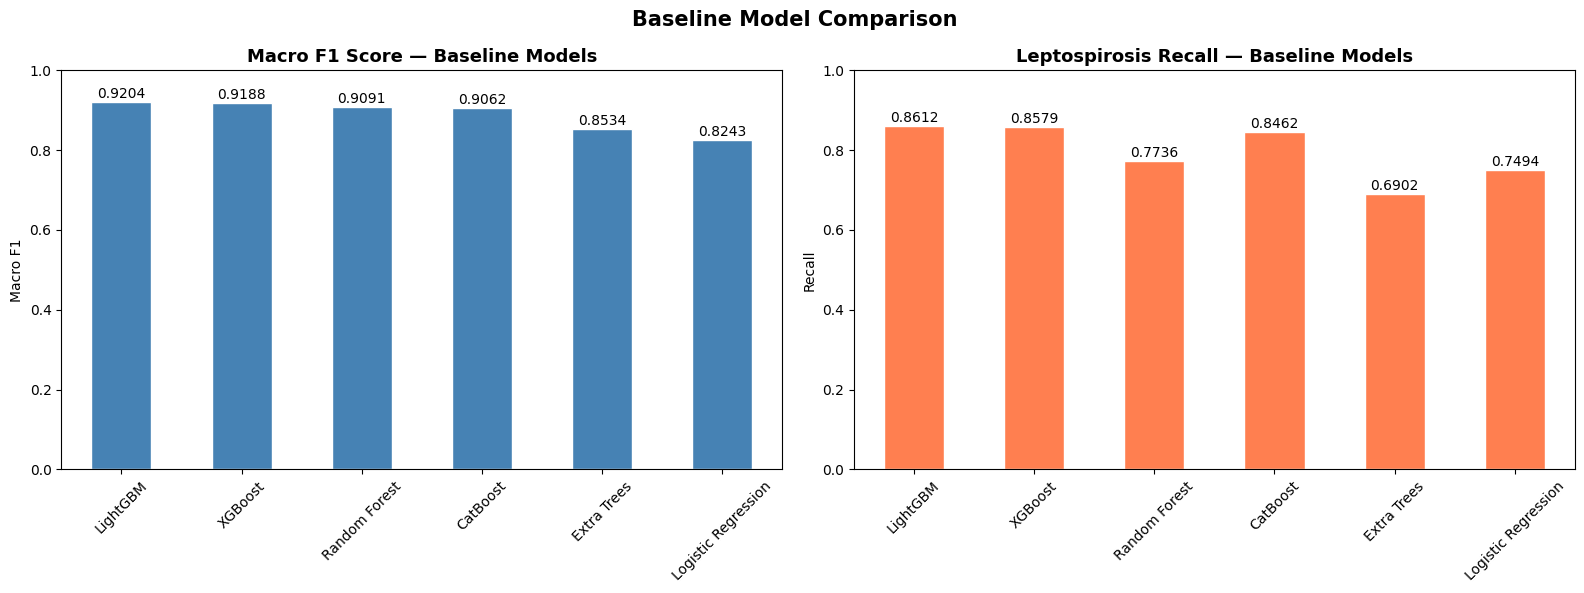

In [23]:
results_df = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print('=== BASELINE MODEL COMPARISON ===')
print(results_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results_df['macro_f1'].plot(kind='bar', ax=axes[0],
                             color='steelblue', edgecolor='white')
axes[0].set_title('Macro F1 Score — Baseline Models', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Macro F1')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
for i, val in enumerate(results_df['macro_f1']):
    axes[0].text(i, val + 0.01, str(val), ha='center', fontsize=10)

results_df['leptospirosis_recall'].plot(kind='bar', ax=axes[1],
                                         color='coral', edgecolor='white')
axes[1].set_title('Leptospirosis Recall — Baseline Models', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
for i, val in enumerate(results_df['leptospirosis_recall']):
    axes[1].text(i, val + 0.01, str(val), ha='center', fontsize=10)

plt.suptitle('Baseline Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Hyperparameter Tuning (Top 3 Models)


In [25]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
sample_weights = compute_sample_weight('balanced', y_train)
print('Ready for tuning')

Ready for tuning



### 5.1 XGBoost Tuned

In [26]:
# Step 1 — RandomizedSearchCV
xgb_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_random.fit(X_train, y_train, sample_weight=sample_weights)
print('XGB Best params (Random):', xgb_random.best_params_)
print('XGB Best F1 (Random):', round(xgb_random.best_score_, 4))

# Step 2 — GridSearchCVr
best_xgb = xgb_random.best_params_
xgb_param_grid = {
    'n_estimators': [best_xgb['n_estimators'] - 100,
                     best_xgb['n_estimators'],
                     best_xgb['n_estimators'] + 100],
    'max_depth': [best_xgb['max_depth'] - 1,
                  best_xgb['max_depth'],
                  best_xgb['max_depth'] + 1],
    'learning_rate': [best_xgb['learning_rate']],
    'subsample': [best_xgb['subsample']],
    'colsample_bytree': [best_xgb['colsample_bytree']],
    'min_child_weight': [best_xgb['min_child_weight']]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    param_grid=xgb_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train, sample_weight=sample_weights)
print('XGB Best params (Grid):', xgb_grid.best_params_)
print('XGB Best F1 (Grid):', round(xgb_grid.best_score_, 4))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGB Best params (Random): {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
XGB Best F1 (Random): 0.9201
Fitting 3 folds for each of 9 candidates, totalling 27 fits
XGB Best params (Grid): {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 600, 'subsample': 0.8}
XGB Best F1 (Grid): 0.9201


2026/08/05 09:26:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


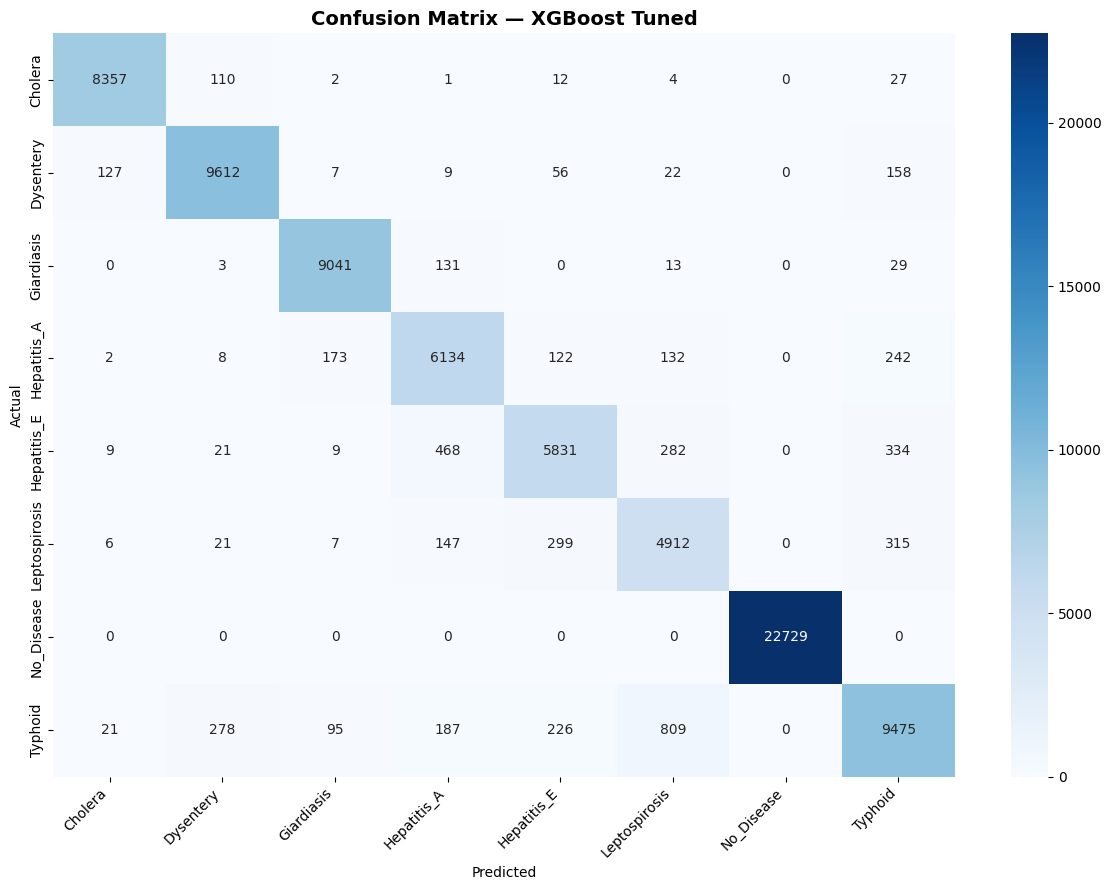

=== XGBoost Tuned ===
{'macro_f1': 0.9204, 'accuracy': 0.9392, 'leptospirosis_recall': 0.8607, 'cholera_recall': 0.9817}


In [27]:
with mlflow.start_run(run_name='XGBoost_tuned'):
    xgb_tuned = xgb_grid.best_estimator_
    metrics = evaluate_model(xgb_tuned, X_test, y_test, le_encoder)
    results['XGBoost Tuned'] = metrics
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(xgb_tuned, 'xgboost_tuned')
    cm_path = plot_confusion_matrix(xgb_tuned, X_test, y_test, le_encoder, 'XGBoost Tuned')
    mlflow.log_artifact(cm_path)
    print('=== XGBoost Tuned ===')
    print(metrics)

### 5.2 LightGBM Tuned

In [28]:
# Step 1 — RandomizedSearchCV
lgbm_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

lgbm_random = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1),
    param_distributions=lgbm_param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgbm_random.fit(X_train, y_train)
print('LGBM Best params (Random):', lgbm_random.best_params_)
print('LGBM Best F1 (Random):', round(lgbm_random.best_score_, 4))

# Step 2 — GridSearchCV
best_lgbm = lgbm_random.best_params_
lgbm_param_grid = {
    'n_estimators': [best_lgbm['n_estimators'] - 100,
                     best_lgbm['n_estimators'],
                     best_lgbm['n_estimators'] + 100],
    'max_depth': [best_lgbm['max_depth'] - 1,
                  best_lgbm['max_depth'],
                  best_lgbm['max_depth'] + 1],
    'learning_rate': [best_lgbm['learning_rate']],
    'num_leaves': [best_lgbm['num_leaves']],
    'subsample': [best_lgbm['subsample']],
    'colsample_bytree': [best_lgbm['colsample_bytree']],
    'min_child_samples': [best_lgbm['min_child_samples']]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1),
    param_grid=lgbm_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
lgbm_grid.fit(X_train, y_train)
print('LGBM Best params (Grid):', lgbm_grid.best_params_)
print('LGBM Best F1 (Grid):', round(lgbm_grid.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
LGBM Best params (Random): {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 30, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
LGBM Best F1 (Random): 0.9199
Fitting 3 folds for each of 9 candidates, totalling 27 fits
LGBM Best params (Grid): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 31, 'subsample': 1.0}
LGBM Best F1 (Grid): 0.9201


2026/08/05 11:20:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


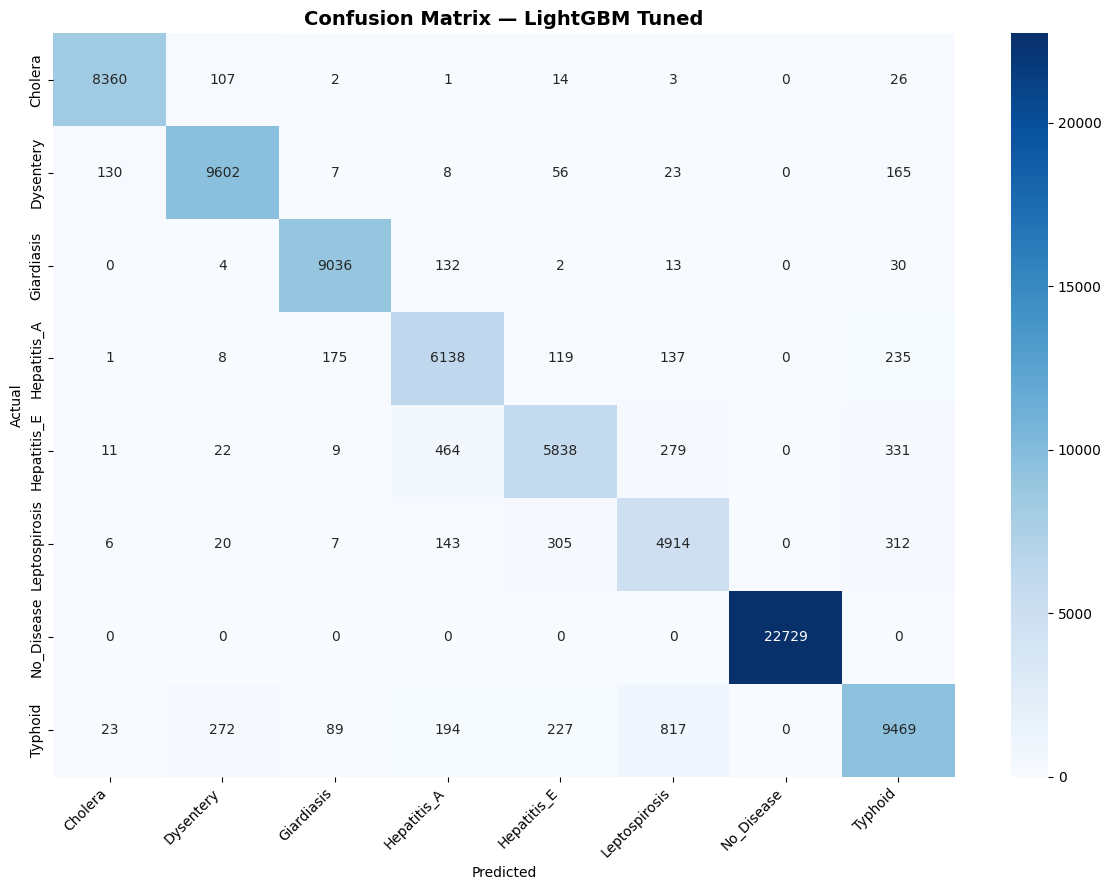

=== LightGBM Tuned ===
{'macro_f1': 0.9204, 'accuracy': 0.9392, 'leptospirosis_recall': 0.861, 'cholera_recall': 0.982}


In [29]:
# MLflow log
with mlflow.start_run(run_name='LightGBM_tuned'):
    lgbm_tuned = lgbm_grid.best_estimator_
    metrics = evaluate_model(lgbm_tuned, X_test, y_test, le_encoder)
    results['LightGBM Tuned'] = metrics
    mlflow.log_params(lgbm_grid.best_params_)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(lgbm_tuned, 'lightgbm_tuned')
    cm_path = plot_confusion_matrix(lgbm_tuned, X_test, y_test, le_encoder, 'LightGBM Tuned')
    mlflow.log_artifact(cm_path)
    print('=== LightGBM Tuned ===')
    print(metrics)

### 5.3 CatBoost Tuned

In [30]:
# Step 1 — RandomizedSearchCV
cat_param_dist = {
    'iterations': [200, 300, 500],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'bagging_temperature': [0, 0.5, 1.0]
}

cat_random = RandomizedSearchCV(
    CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, verbose=0),
    param_distributions=cat_param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
cat_random.fit(X_train, y_train)
print('CatBoost Best params (Random):', cat_random.best_params_)
print('CatBoost Best F1 (Random):', round(cat_random.best_score_, 4))

# Step 2 — GridSearchCV
best_cat = cat_random.best_params_
cat_param_grid = {
    'iterations': [best_cat['iterations'] - 100,
                   best_cat['iterations'],
                   best_cat['iterations'] + 100],
    'depth': [best_cat['depth'] - 1,
              best_cat['depth'],
              best_cat['depth'] + 1],
    'learning_rate': [best_cat['learning_rate']],
    'l2_leaf_reg': [best_cat['l2_leaf_reg']],
    'bagging_temperature': [best_cat['bagging_temperature']]
}

cat_grid = GridSearchCV(
    CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, verbose=0),
    param_grid=cat_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
cat_grid.fit(X_train, y_train)
print('CatBoost Best params (Grid):', cat_grid.best_params_)
print('CatBoost Best F1 (Grid):', round(cat_grid.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CatBoost Best params (Random): {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 8, 'bagging_temperature': 1.0}
CatBoost Best F1 (Random): 0.915
Fitting 3 folds for each of 9 candidates, totalling 27 fits
CatBoost Best params (Grid): {'bagging_temperature': 1.0, 'depth': 7, 'iterations': 600, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
CatBoost Best F1 (Grid): 0.9156


2026/08/05 13:49:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


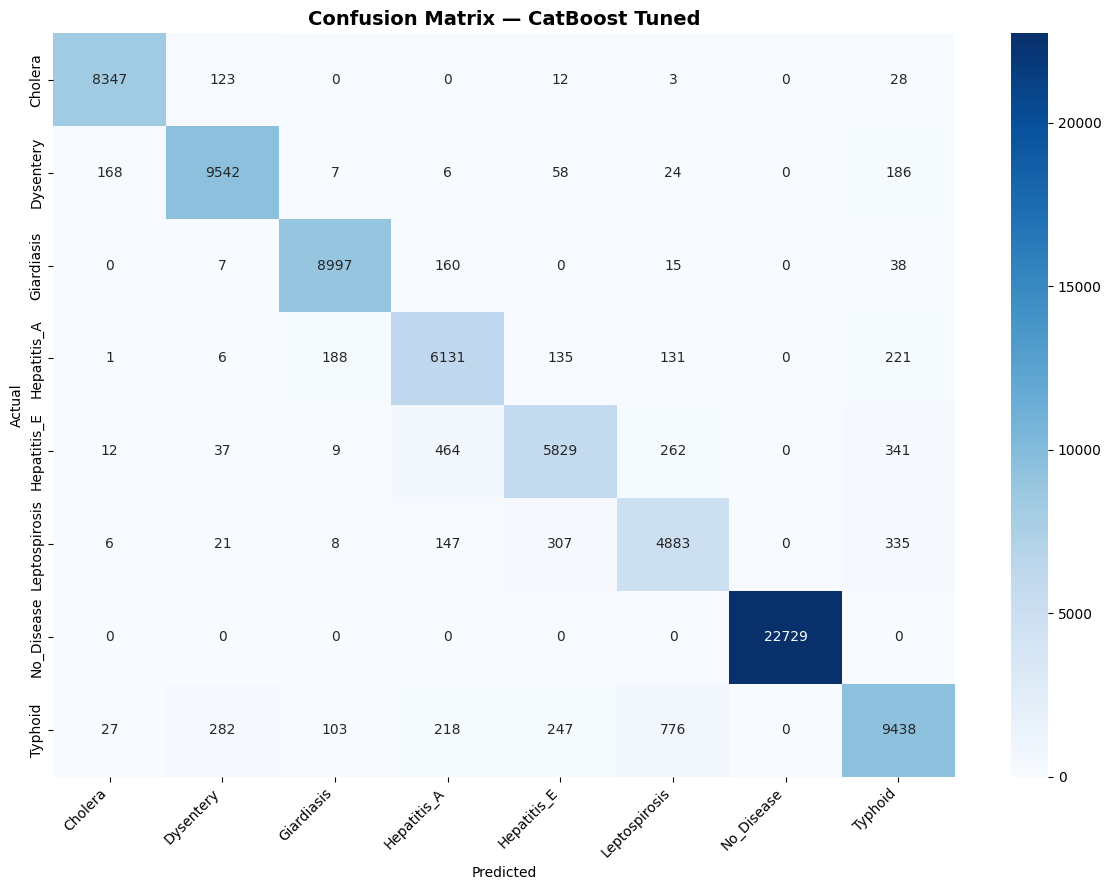

=== CatBoost Tuned ===
{'macro_f1': 0.9177, 'accuracy': 0.9368, 'leptospirosis_recall': 0.8556, 'cholera_recall': 0.9805}


In [31]:
# MLflow log
with mlflow.start_run(run_name='CatBoost_tuned'):
    cat_tuned = cat_grid.best_estimator_
    metrics = evaluate_model(cat_tuned, X_test, y_test, le_encoder)
    results['CatBoost Tuned'] = metrics
    mlflow.log_params(cat_grid.best_params_)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(cat_tuned, 'catboost_tuned')
    cm_path = plot_confusion_matrix(cat_tuned, X_test, y_test, le_encoder, 'CatBoost Tuned')
    mlflow.log_artifact(cm_path)
    print('=== CatBoost Tuned ===')
    print(metrics)

---
## 6. Stacking Ensemble

Training stacking ensemble — this will take 10-15 minutes...


2026/08/05 14:10:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


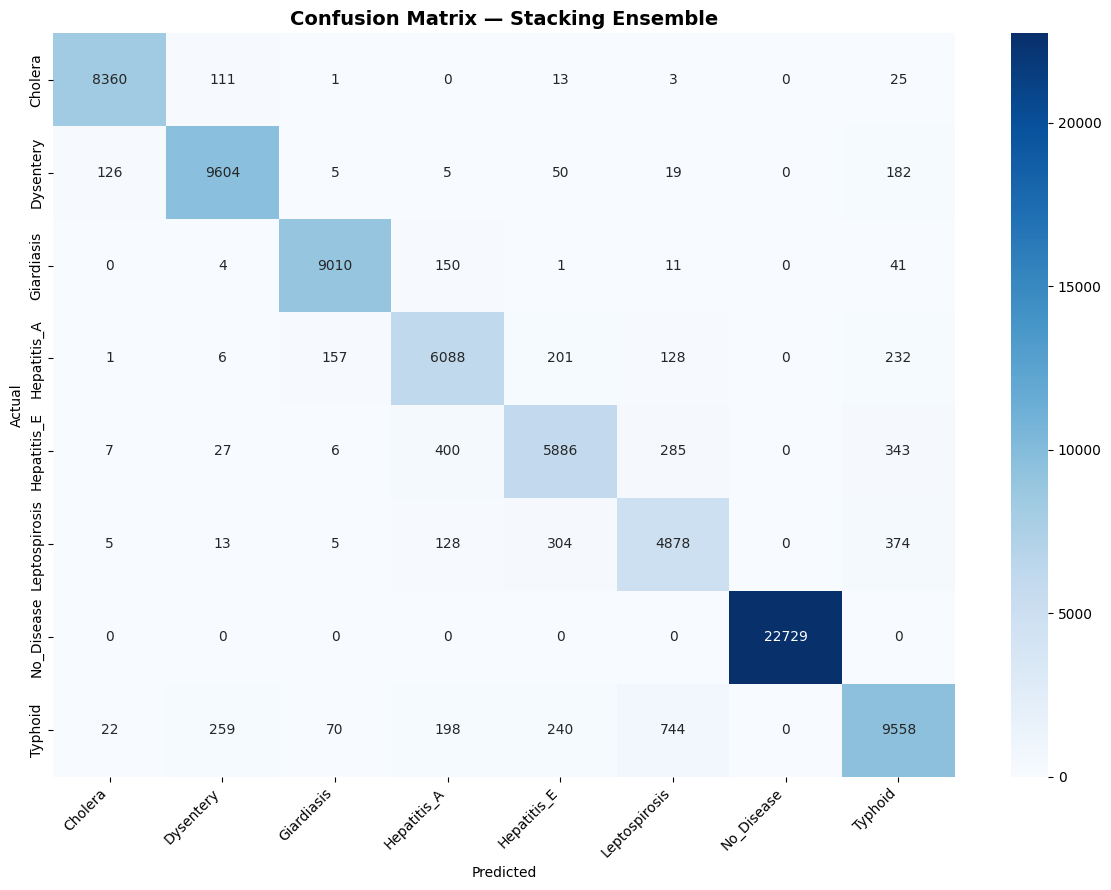


=== STACKING ENSEMBLE ===
{'macro_f1': 0.9208, 'accuracy': 0.9395, 'leptospirosis_recall': 0.8547, 'cholera_recall': 0.982}


In [32]:
with mlflow.start_run(run_name='Stacking_Ensemble_final'):

    # Tuned versions for stacking ensemble
    estimators = [
        ('xgb', xgb_grid.best_estimator_),
        ('lgbm', lgbm_grid.best_estimator_),
        ('cat', cat_grid.best_estimator_)
    ]

    # Meta learner
    meta_learner = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

    stacking = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1
    )

    print('Training stacking ensemble — this will take 10-15 minutes...')
    stacking.fit(X_train, y_train)

    metrics = evaluate_model(stacking, X_test, y_test, le_encoder)
    results['Stacking Ensemble'] = metrics

    mlflow.log_param('model', 'StackingEnsemble')
    mlflow.log_param('base_models', 'XGBoost+LightGBM+CatBoost')
    mlflow.log_param('meta_learner', 'LogisticRegression')
    mlflow.log_param('cv_folds', 5)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(stacking, 'stacking_ensemble')

    cm_path = plot_confusion_matrix(stacking, X_test, y_test, le_encoder, 'Stacking Ensemble')
    mlflow.log_artifact(cm_path)

    print('\n=== STACKING ENSEMBLE ===')
    print(metrics)

### Full Results Comparison

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('macro_f1', ascending=False)
print('=== ALL MODELS COMPARISON ===')
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(14, 7))
results_df[['macro_f1', 'accuracy', 'leptospirosis_recall', 'cholera_recall']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='white'
)
ax.set_title('All Models — Full Metric Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower right')
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target F1=0.85')
plt.tight_layout()
plt.savefig('plots/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. SHAP Explainability

In [33]:
# Use CatBoost tuned for SHAP (fastest SHAP support)
print('Computing SHAP values — using CatBoost tuned model...')

# Sample for speed (SHAP on 405K rows is slow)
X_shap = X_test.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(cat_tuned)
shap_values = explainer.shap_values(X_shap)

print('SHAP values computed')
print('Shape:', np.array(shap_values).shape)

Computing SHAP values — using CatBoost tuned model...


: 

In [ ]:
# Global feature importance — mean absolute SHAP across all classes
shap_abs_mean = np.abs(np.array(shap_values)).mean(axis=0).mean(axis=0)
shap_importance = pd.Series(shap_abs_mean, index=X_shap.columns)
shap_importance = shap_importance.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
shap_importance.head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Features — Global SHAP Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
print(shap_importance.head(10))

In [ ]:
# SHAP summary plot for each disease class
disease_names = le_encoder.classes_

for i, disease in enumerate(disease_names):
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_values[i],
        X_shap,
        plot_type='bar',
        max_display=15,
        show=False
    )
    plt.title(f'SHAP Feature Importance — {disease}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/shap_{disease}.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()